<a href="https://colab.research.google.com/github/caviteri/Ciencia-de-Datos-2026/blob/main/Ciencia_de_Datos_Semana_08_Inferencia_Cl%C3%A1sica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller: Inferencia Clásica y Bayesiana en Series Energéticas

## Parte 1: Planteamiento del Problema

Imaginemos que estamos evaluando el potencial de generación fotovoltaica en una región específica (por ejemplo, Pasto, Nariño). Tenemos un sensor que mide la irradiancia solar ($W/m^2$) todos los días exactamente al mediodía.

Sin embargo, debido a la variabilidad climática (nubosidad aleatoria, aerosoles) y al ruido térmico del propio sensor, nuestras mediciones fluctúan. Asumiremos que la irradiancia al mediodía durante este mes proviene de una distribución Gaussiana con una media $\mu$ (el valor real subyacente que queremos conocer para dimensionar el panel) y una varianza $\sigma^2$ (la incertidumbre/ruido).

**Objetivo:**
Estimar los parámetros desconocidos $\mu$ y $\sigma^2$ a partir de nuestras observaciones limitadas utilizando Inferencia Clásica (Máxima Verosimilitud).

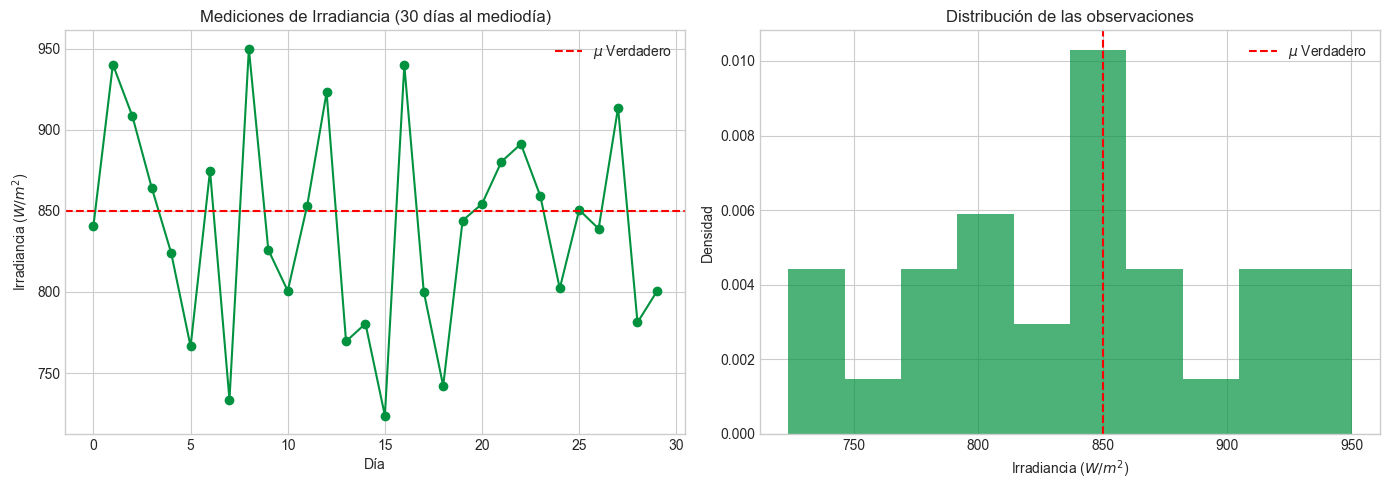

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Configuración estética de las gráficas
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


# 1. GENERACIÓN DE DATOS SINTÉTICOS
#np.random.seed(42) # Para reproducibilidad en clase

# Parámetros "Verdaderos" (Desconocidos para el estimador)
mu_true = 850.0    # Irradiancia media real en W/m^2
sigma_true = 75.0  # Desviación estándar (ruido/clima)

# Simulamos 30 días de mediciones independientes (n=30)
n_samples = 30
mediciones = np.random.normal(loc=mu_true, scale=sigma_true, size=n_samples)

# Visualización de los datos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de serie de tiempo
ax1.plot(mediciones, marker='o', linestyle='-', color='#00923F') # Usando verde Udenar
ax1.axhline(mu_true, color='red', linestyle='--', label=r'$\mu$ Verdadero')
ax1.set_title('Mediciones de Irradiancia (30 días al mediodía)')
ax1.set_xlabel('Día')
ax1.set_ylabel('Irradiancia ($W/m^2$)')
ax1.legend()

# Histograma
ax2.hist(mediciones, bins=10, density=True, alpha=0.7, color='#00923F')
ax2.axvline(mu_true, color='red', linestyle='--', label=r'$\mu$ Verdadero')
ax2.set_title('Distribución de las observaciones')
ax2.set_xlabel('Irradiancia ($W/m^2$)')
ax2.set_ylabel('Densidad')
ax2.legend()

plt.tight_layout()
plt.show()

## Parte 2: Estimación de Máxima Verosimilitud (MLE)

En Inferencia Clásica, los parámetros $\theta = (\mu, \sigma)$ son valores fijos pero desconocidos. El objetivo del estimador de Máxima Verosimilitud (MLE) es encontrar los valores de $\mu$ y $\sigma$ que hacen que los datos observados sean lo más "probables" posible.

Dado un vector de observaciones independientes $\mathbf{x} = [x_1, x_2, \dots, x_n]^T$, la función de verosimilitud conjunta asumiendo ruido Gaussiano es:

$$L(\mu, \sigma) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(x_i - \mu)^2}{2\sigma^2} \right)$$

Para facilitar la optimización, minimizamos el logaritmo negativo de la verosimilitud (Negative Log-Likelihood o NLL):

$$\text{NLL}(\mu, \sigma) = \frac{n}{2}\ln(2\pi) + n\ln(\sigma) + \frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i - \mu)^2$$

In [2]:
# 2. DEFINICIÓN DE LA FUNCIÓN DE LOG-VEROSIMILITUD NEGATIVA (NLL)

def negative_log_likelihood(params, data):
    """
    Calcula el NLL asumiendo una distribución Gaussiana.
    params: lista o array con [mu, sigma]
    data: array con las observaciones
    """
    mu, sigma = params

    # Restricción: la desviación estándar no puede ser negativa o cero
    if sigma <= 0:
        return np.inf

    n = len(data)
    # Ecuación del NLL
    term1 = (n / 2) * np.log(2 * np.pi)
    term2 = n * np.log(sigma)
    term3 = np.sum((data - mu)**2) / (2 * sigma**2)

    return term1 + term2 + term3

### 2.1 Optimización Numérica
Vamos a utilizar la librería `scipy.optimize` para encontrar el mínimo de nuestra función NLL, lo cual es equivalente a maximizar la Verosimilitud.

In [3]:
# Valores iniciales (guesses) para el optimizador
# Empezamos con una suposición aleatoria razonable
initial_guess = [500.0, 10.0]

# Ejecutamos la minimización
resultado_mle = minimize(
    negative_log_likelihood,
    initial_guess,
    args=(mediciones,),
    method='L-BFGS-B',
    bounds=[(None, None), (1e-5, None)] # Sigma debe ser estrictamente positivo
)

mu_mle, sigma_mle = resultado_mle.x

print("--- RESULTADOS DE OPTIMIZACIÓN NUMÉRICA (MLE) ---")
print(f"Mu Verdadero:\t\t {mu_true:.2f}")
print(f"Mu Estimado (MLE):\t {mu_mle:.2f}")
print(f"Sigma Verdadero:\t {sigma_true:.2f}")
print(f"Sigma Estimado (MLE):\t {sigma_mle:.2f}")

--- RESULTADOS DE OPTIMIZACIÓN NUMÉRICA (MLE) ---
Mu Verdadero:		 850.00
Mu Estimado (MLE):	 839.30
Sigma Verdadero:	 75.00
Sigma Estimado (MLE):	 61.81


### 2.2 Comparación Analítica
Como vieron en las clases teóricas (Parte 4b), para una distribución Gaussiana, el proceso de derivar e igualar a cero la función de log-verosimilitud tiene una solución analítica cerrada:

$$\hat{\mu}_{ML} = \frac{1}{n}\sum_{i=1}^{n} x_i = \bar{x}$$
$$\hat{\sigma}^2_{ML} = \frac{1}{n}\sum_{i=1}^{n} (x_i - \bar{x})^2$$

Verifiquemos que el optimizador numérico llegó al mismo resultado que las matemáticas exactas.

In [4]:
# Cálculo analítico (Media muestral y desviación estándar poblacional sesgada)
mu_analitico = np.mean(mediciones)
sigma_analitico = np.std(mediciones, ddof=0) # ddof=0 para MLE de la varianza

print("--- COMPARACIÓN NUMÉRICO VS ANALÍTICO ---")
print(f"Mu Numérico:\t {mu_mle:.4f} \t| Mu Analítico:\t {mu_analitico:.4f}")
print(f"Sigma Numérico:\t {sigma_mle:.4f} \t| Sigma Analítico: {sigma_analitico:.4f}")

# Comprobación de que son prácticamente idénticos
assert np.isclose(mu_mle, mu_analitico), "Las medias no coinciden"
assert np.isclose(sigma_mle, sigma_analitico), "Las sigmas no coinciden"
print("\n¡Éxito! El optimizador numérico encontró la solución analítica exacta.")

--- COMPARACIÓN NUMÉRICO VS ANALÍTICO ---
Mu Numérico:	 839.2988 	| Mu Analítico:	 839.2987
Sigma Numérico:	 61.8096 	| Sigma Analítico: 61.8096

¡Éxito! El optimizador numérico encontró la solución analítica exacta.


### 2.3 Visualización de la Superficie de Verosimilitud
Para entender por qué el algoritmo de optimización se detuvo en ese punto específico, podemos graficar la superficie bidimensional de la función de Log-Verosimilitud Negativa. El punto más bajo (el valle más profundo) corresponde a nuestro estimador MLE.

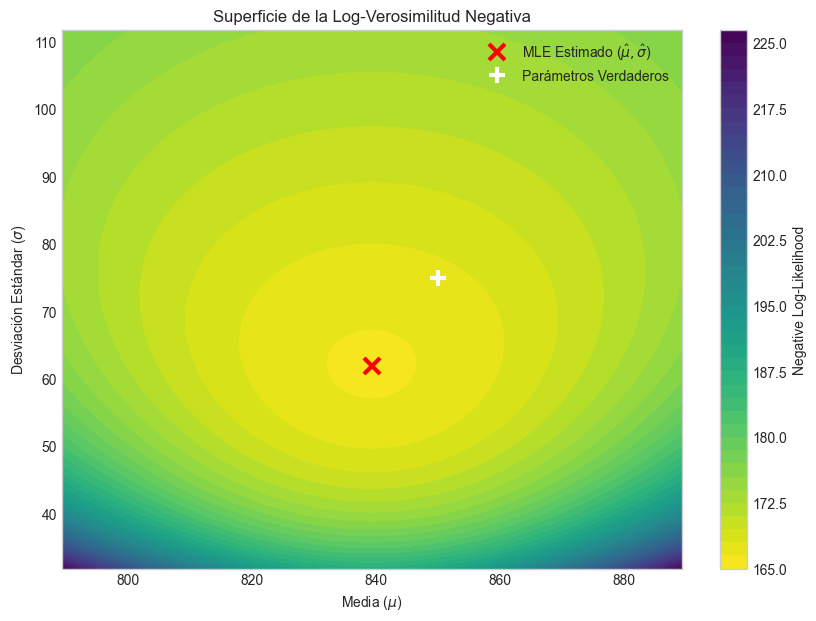

In [5]:
# Crear una grilla de valores para mu y sigma alrededor de nuestros estimados
mu_vals = np.linspace(mu_mle - 50, mu_mle + 50, 100)
sigma_vals = np.linspace(sigma_mle - 30, sigma_mle + 50, 100)

Mu_grid, Sigma_grid = np.meshgrid(mu_vals, sigma_vals)
NLL_grid = np.zeros_like(Mu_grid)

# Llenar la grilla evaluando la función NLL
for i in range(100):
    for j in range(100):
        NLL_grid[i, j] = negative_log_likelihood([Mu_grid[i, j], Sigma_grid[i, j]], mediciones)

# Graficar contornos
plt.figure(figsize=(10, 7))
cp = plt.contourf(Mu_grid, Sigma_grid, NLL_grid, levels=50, cmap='viridis_r')
plt.colorbar(cp, label='Negative Log-Likelihood')

# Marcar el punto óptimo encontrado
plt.plot(mu_mle, sigma_mle, 'rx', markersize=12, markeredgewidth=3, label=r'MLE Estimado ($\hat{\mu}, \hat{\sigma}$)')
# Marcar el punto verdadero
plt.plot(mu_true, sigma_true, 'w+', markersize=12, markeredgewidth=3, label='Parámetros Verdaderos')

plt.title('Superficie de la Log-Verosimilitud Negativa')
plt.xlabel(r'Media ($\mu$)')
plt.ylabel(r'Desviación Estándar ($\sigma$)')
plt.legend()
plt.show()

## Parte 3: MLE Aplicado a Rendimientos del Petróleo WTI

En el **Reto 2 de la Semana 07** se modelaron los log-rendimientos diarios del petróleo WTI (`CL=F`) como un proceso ARMA(2,2) estacionario. Antes de modelar la *dinámica* de esa serie, una pregunta válida es: ¿cuáles son los **parámetros de su distribución marginal**?

Aplicamos el mismo MLE que usamos con la irradiancia solar, pero sobre los log-rendimientos reales del WTI. Asumimos que estos siguen (aproximadamente) una distribución Gaussiana:

$$R_t \sim \mathcal{N}(\mu, \sigma^2)$$

y estimamos sus parámetros a partir de los datos históricos.

Observaciones (n):           1567
Media muestral (≈ 0):        -0.00000000000000000907%
Desv. Estándar muestral:     3.2188%


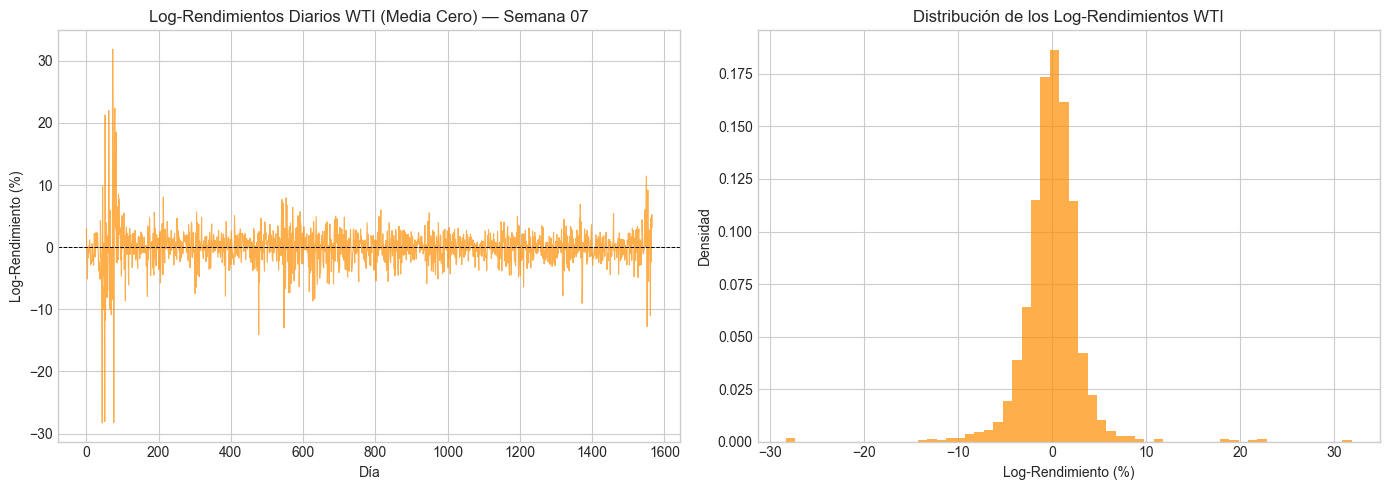

In [6]:
import yfinance as yf
import scipy.stats as stats

# Descarga de datos WTI
ticker_wti = 'CL=F'
data_wti   = yf.download(ticker_wti, start='2020-01-01', end='2026-03-31', progress=False)
precios_wti = data_wti['Close'].squeeze().dropna().astype(float)

# Log-rendimientos diarios
_ratio_wti = precios_wti / precios_wti.shift(1)
_valid = (_ratio_wti > 0) & np.isfinite(_ratio_wti)
log_rend_wti = np.log(_ratio_wti.where(_valid)).dropna() * 100
media_wti    = log_rend_wti.mean()
datos_wti    = (log_rend_wti - media_wti).values   # proceso de media cero

print(f"Observaciones (n):           {len(datos_wti)}")
print(f"Media muestral (≈ 0):        {datos_wti.mean():.20f}%")
print(f"Desv. Estándar muestral:     {datos_wti.std():.4f}%")

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(datos_wti, color='darkorange', alpha=0.7, linewidth=0.8)
ax1.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax1.set_title('Log-Rendimientos Diarios WTI (Media Cero) — Semana 07')
ax1.set_xlabel('Día')
ax1.set_ylabel('Log-Rendimiento (%)')

ax2.hist(datos_wti, bins=60, density=True, color='darkorange', alpha=0.7)
ax2.set_title('Distribución de los Log-Rendimientos WTI')
ax2.set_xlabel('Log-Rendimiento (%)')
ax2.set_ylabel('Densidad')
plt.tight_layout()
plt.show()

### 3.1 MLE Analítico y Ajuste Gráfico

Aplicamos las fórmulas cerradas del MLE Gaussiano sobre los log-rendimientos del WTI y superponemos la distribución ajustada al histograma de los datos reales.

--- MLE APLICADO A LOG-RENDIMIENTOS WTI ---
n (observaciones):      1567
μ̂_MLE (media):         -0.000000%
σ̂_MLE (desv. estándar):3.2188%


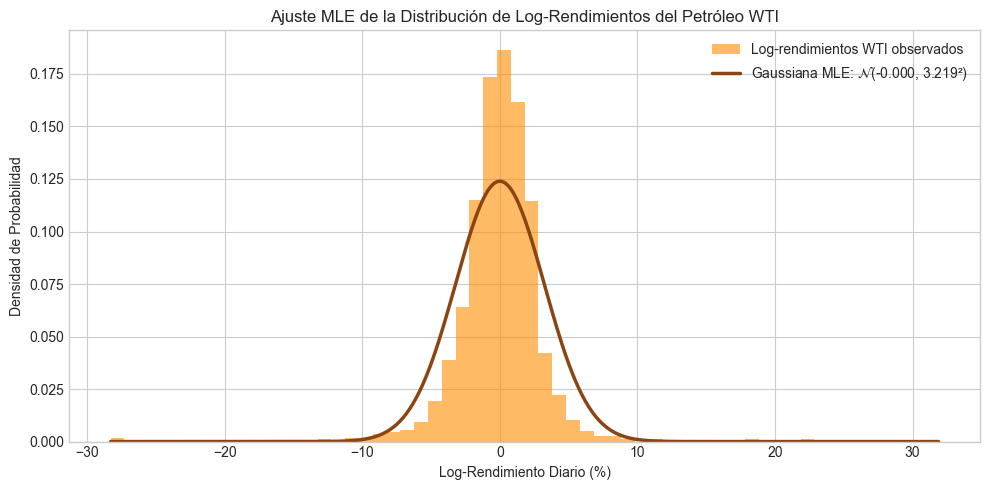

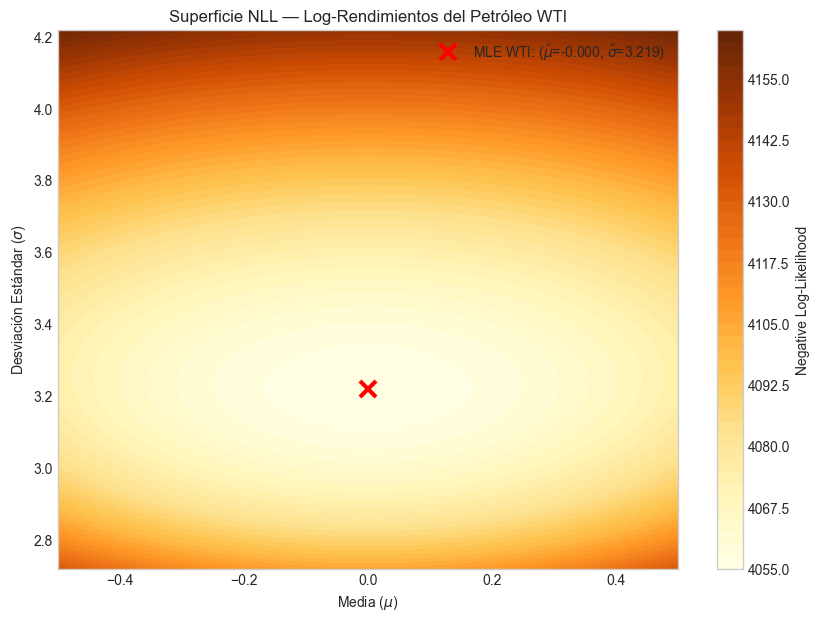

In [7]:
# MLE analítico (solución cerrada)
n_wti        = len(datos_wti)
mu_mle_wti   = np.mean(datos_wti)           # ≈ 0 por construcción
sigma_mle_wti = np.std(datos_wti, ddof=0)   # MLE de sigma

print("--- MLE APLICADO A LOG-RENDIMIENTOS WTI ---")
print(f"n (observaciones):      {n_wti}")
print(f"μ̂_MLE (media):         {mu_mle_wti:.6f}%")
print(f"σ̂_MLE (desv. estándar):{sigma_mle_wti:.4f}%")

# Ajuste gráfico
x_wti = np.linspace(datos_wti.min(), datos_wti.max(), 500)
pdf_wti = stats.norm.pdf(x_wti, loc=mu_mle_wti, scale=sigma_mle_wti)

plt.figure(figsize=(10, 5))
plt.hist(datos_wti, bins=60, density=True, color='darkorange',
         alpha=0.6, label='Log-rendimientos WTI observados')
plt.plot(x_wti, pdf_wti, color='saddlebrown', lw=2.5,
         label=rf'Gaussiana MLE: $\mathcal{{N}}$({mu_mle_wti:.3f}, {sigma_mle_wti:.3f}²)')
plt.title('Ajuste MLE de la Distribución de Log-Rendimientos del Petróleo WTI')
plt.xlabel('Log-Rendimiento Diario (%)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.tight_layout()
plt.show()

# Superficie NLL alrededor del óptimo WTI
mu_vals_wti    = np.linspace(mu_mle_wti - 0.5, mu_mle_wti + 0.5, 100)
sigma_vals_wti = np.linspace(sigma_mle_wti - 0.5, sigma_mle_wti + 1.0, 100)
Mu_g, Sigma_g  = np.meshgrid(mu_vals_wti, sigma_vals_wti)
NLL_g = np.array([[negative_log_likelihood([Mu_g[i,j], Sigma_g[i,j]], datos_wti)
                   for j in range(100)] for i in range(100)])

plt.figure(figsize=(10, 7))
cp = plt.contourf(Mu_g, Sigma_g, NLL_g, levels=50, cmap='YlOrBr')
plt.colorbar(cp, label='Negative Log-Likelihood')
plt.plot(mu_mle_wti, sigma_mle_wti, 'rx', markersize=12, markeredgewidth=3,
         label=rf'MLE WTI: ($\hat\mu$={mu_mle_wti:.3f}, $\hat\sigma$={sigma_mle_wti:.3f})')
plt.title('Superficie NLL — Log-Rendimientos del Petróleo WTI')
plt.xlabel(r'Media ($\mu$)')
plt.ylabel(r'Desviación Estándar ($\sigma$)')
plt.legend()
plt.show()